In [4]:
import polars as pl
from PIL import Image, ImageDraw

import io

In [5]:
# Read the Parquet file into a Polars DataFrame
df = pl.read_parquet(
    "/home/frank/Code/multumbabel/lab/finetuning/rtdetr/dataset/results_unmsm_2025.parquet",
    # memory_map=True,
)

# Print the first few rows of the DataFrame
print(df.head())

shape: (5, 7)
┌──────────────┬──────────────┬──────────────┬──────────────┬─────────┬──────────────┬─────────────┐
│ image        ┆ bboxes       ┆ label        ┆ confidence   ┆ page_no ┆ filename     ┆ pathfile    │
│ ---          ┆ ---          ┆ ---          ┆ ---          ┆ ---     ┆ ---          ┆ ---         │
│ binary       ┆ list[list[f6 ┆ list[str]    ┆ list[f64]    ┆ i64     ┆ str          ┆ str         │
│              ┆ 4]]          ┆              ┆              ┆         ┆              ┆             │
╞══════════════╪══════════════╪══════════════╪══════════════╪═════════╪══════════════╪═════════════╡
│ b"\x89PNG\x0 ┆ [[105.672426 ┆ ["picture",  ┆ [0.567798,   ┆ 1       ┆ SOL_Adm_UNMS ┆ /home/frank │
│ d\x0a\x1a\x0 ┆ , 16.27193,  ┆ "picture", … ┆ 0.66437, …   ┆         ┆ M 2025-I -   ┆ /Datalake/d │
│ a\x00\…      ┆ … 57.1…      ┆ "pict…       ┆ 0.600615…    ┆         ┆ area D.…     ┆ atasets/…   │
│ b"\x89PNG\x0 ┆ [[0.043794,  ┆ ["picture"]  ┆ [0.651403]   ┆ 2       ┆ SOL_A

In [6]:
image_bytes = df[0]["image"].to_list()[0]
print(len(image_bytes))
# print(image_bytes.keys())
# print(image_bytes["path"])

image = Image.open(io.BytesIO(image_bytes))
image.size
# image.show()

331483


(468, 615)

In [7]:
bbox = df[0]["bboxes"].to_list()[0]
print(bbox)

[[105.67242597309657, 16.271929967935197, 251.28378181840958, 57.18065802478703], [277.3628447220701, 18.770850832019075, 379.8216499367649, 57.52548246850868], [0.2648276465500046, 64.01529787224463, 468.2272186930691, 569.6715375617192], [183.14022092043854, 582.5038999028523, 203.37598305014743, 602.2983351116129], [343.90848504624546, 582.5454899928886, 363.39420562931946, 601.8122223122966], [18.09096775178582, 583.0440824966425, 37.60118587504456, 602.337695236589]]


In [8]:
index = 1
# Load image bytes from the DataFrame
image_bytes = df[index]["image"].to_list()[0]
print("Image bytes length:", len(image_bytes))

# Open the image from bytes
image = Image.open(io.BytesIO(image_bytes))
print("Image size:", image.size)  # For example: (595, 842)

# Get the bounding boxes (assumed format: [x1, y1, x2, y2])
bboxes = df[index]["bboxes"].to_list()[0]
print("Bounding boxes:", bboxes)

# Create a drawing object
draw = ImageDraw.Draw(image)

# Draw each bounding box on the image
for box in bboxes:
    # Draw a red rectangle with a line width of 2
    draw.rectangle(box, outline="red", width=2)

# Display the image with bounding boxes
image.show()

Image bytes length: 305159
Image size: (468, 615)
Bounding boxes: [[0.04379369492379398, 50.293469084312164, 466.7983151151258, 598.4511117331424]]


Opening in existing browser session.


In [2]:
# Read the Parquet file into a Polars DataFrame
df = pl.read_parquet(
    "/home/frank/Code/multumbabel/lab/finetuning/rtdetr/dataset/output_annotations.parquet",
    # memory_map=True,
)

# Print the first few rows of the DataFrame
print(df.head())

shape: (5, 4)
┌──────────────────────────────┬─────────────────────────────┬───────────────────┬─────────────────┐
│ image_path                   ┆ image_base64                ┆ bboxes            ┆ labels          │
│ ---                          ┆ ---                         ┆ ---               ┆ ---             │
│ str                          ┆ binary                      ┆ list[list[f64]]   ┆ list[str]       │
╞══════════════════════════════╪═════════════════════════════╪═══════════════════╪═════════════════╡
│ /data/local-files/?d=images_ ┆ b"\x89PNG\x0d\x0a\x1a\x0a\x ┆ [[230.892621,     ┆ ["page_footer", │
│ fr…                          ┆ 00\…                        ┆ 592.317143, … 60… ┆ "page_header",… │
│ /data/local-files/?d=images_ ┆ b"\x89PNG\x0d\x0a\x1a\x0a\x ┆ [[230.892621,     ┆ ["page_footer", │
│ fr…                          ┆ 00\…                        ┆ 592.317143, … 60… ┆ "page_header",… │
│ /data/local-files/?d=images_ ┆ b"\x89PNG\x0d\x0a\x1a\x0a\x ┆ [[230.892621, 

In [3]:
index = 0
# Load image bytes from the DataFrame
image_bytes = df[index]["image_base64"].to_list()[0]
print("Image bytes length:", len(image_bytes))

# Open the image from bytes
image = Image.open(io.BytesIO(image_bytes))
print("Image size:", image.size)  # For example: (595, 842)

# Get the bounding boxes (assumed format: [x1, y1, x2, y2])
bboxes = df[index]["bboxes"].to_list()[0]
print("Bounding boxes:", bboxes)

# Create a drawing object
draw = ImageDraw.Draw(image)

# Draw each bounding box on the image
for box in bboxes:
    # Draw a red rectangle with a line width of 2
    draw.rectangle(box, outline="red", width=2)

# Display the image with bounding boxes
image.show()

Image bytes length: 297991
Image size: (468, 615)
Bounding boxes: [[230.89262096524178, 592.3171430699667, 237.1063784296915, 600.336813424416], [302.3958590344161, 18.715316168823666, 440.5564048345474, 28.135601624403826], [44.340812927475376, 16.93223803511725, 126.97678296918866, 29.242389265149132], [28.363151221785824, 51.0938937943029, 102.47796851514912, 59.80652492692471], [28.363151221785824, 64.08074626196549, 156.10739827716336, 72.11116403681886], [28.363151221785824, 86.09405655463651, 227.95184267409567, 105.10483354413302], [28.363151221785824, 108.10736684730766, 228.0068759527663, 127.10061321567574], [28.363151221785824, 130.12067713997868, 227.95584509436262, 149.09639288721846], [28.363151221785824, 152.13398743264975, 227.90581484102566, 171.09217255876112], [28.363151221785824, 174.14729772532078, 227.95384388422914, 193.08795223030384], [28.363151221785824, 206.604923146851, 83.8767203244697, 215.1937108002043], [28.363151221785824, 219.59277621952683, 151.59867

[5049:5075:0304/225445.159773:ERROR:get_updates_processor.cc(266)] PostClientToServerMessage() failed during GetUpdates with error Network error (ERR_ABORTED)


In [5]:
from datasets import load_dataset, load_from_disk
dataset_1 = load_dataset("cppe-5")
dataset_2 = load_from_disk("/home/frank/Code/multumbabel/lab/finetuning/rtdetr/dataset/dataset_exams_2")


In [1]:
# dataset_1["train"][0]

In [7]:
dataset_2["train"][1]

{'image_id': 188,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=468x615>,
 'width': 468,
 'height': 615,
 'objects': {'area': [49.83228652738553,
   570.5843621249185,
   6853.187996168532,
   1090.4238108068782,
   1015.6706738648127,
   866.2017555781241,
   384.5355592056369,
   16930.90233261495,
   21464.208683386594,
   26009.170489676573,
   12324.911033379858,
   46555.17020349114,
   151.65385455684063,
   151.6538545568404,
   151.6538545568402,
   151.65385455684063,
   151.65385455684063,
   844.9059688372599,
   623.2237426368764,
   876.3912188271424,
   390.29549779330273,
   548.4109165333992,
   548.7000340386935,
   657.1649570145686,
   651.9401601184151,
   2255.3101998419484,
   1106.6709699519265,
   976.1286756324178],
  'bbox': [[230.89262096524178,
    592.3171430699667,
    6.2137574644497136,
    8.019670354449318],
   [202.42640742158184,
    69.78119302275397,
    65.54863731701008,
    8.704747886144844],
   [75.68276543294343,
    43.8555

In [7]:
len(dataset_2["train"])

244

Loading dataset from: /home/frank/Code/multumbabel/lab/finetuning/rtdetr/dataset/dataset_exams
Dataset loaded successfully.
Available splits: ['train', 'test']
Accessing sample 2 from split 'train'...
Sample accessed.
Image size: (468, 615) (Width: 468, Height: 615)
Found 53 bounding boxes.
Loaded default font for labels.
Displaying image with bounding boxes...


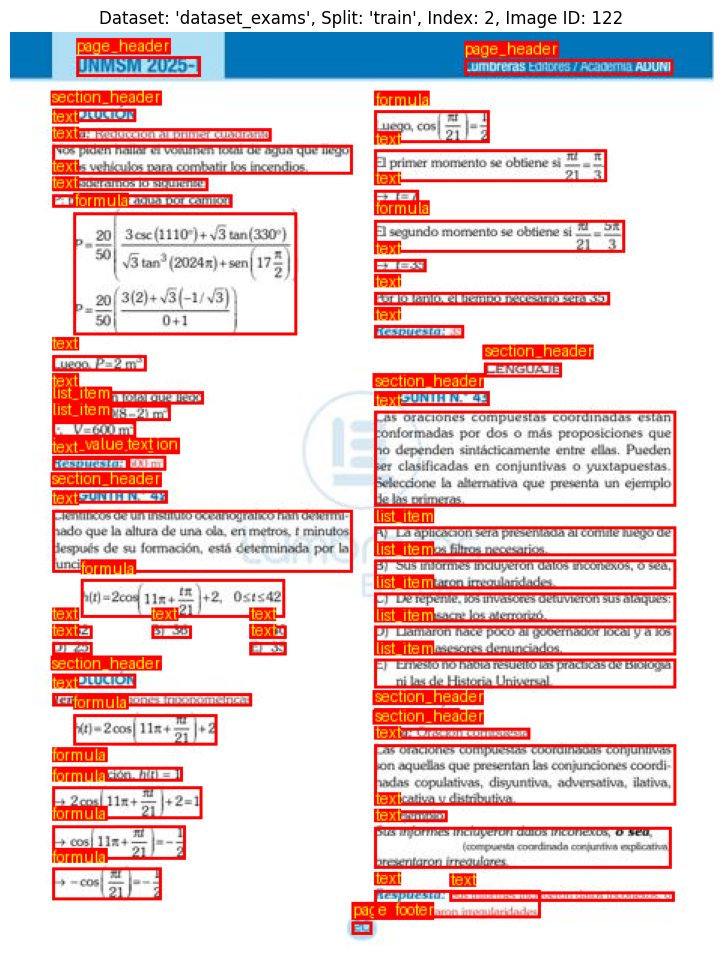

In [8]:
from datasets import load_dataset, load_from_disk
from PIL import Image, ImageDraw, ImageFont # Import ImageDraw and ImageFont
import matplotlib.pyplot as plt # Use matplotlib for better display control
import os # To check if dataset path exists

# --- Configuration ---
dataset_path = "/home/frank/Code/multumbabel/lab/finetuning/rtdetr/dataset/dataset_exams"
image_index_to_plot = 2  # Choose which image index to plot (e.g., the first one)
data_split = "train"     # Choose the split ('train', 'validation', 'test', etc.)
outline_color = "red"    # Color for the bounding boxes
line_width = 2           # Width of the bounding box lines
show_labels = True       # Set to True to display category names
label_color = "yellow"   # Color for the labels
font_size = 12           # Font size for labels

# --- Load Dataset ---
if not os.path.exists(dataset_path):
    print(f"Error: Dataset path not found: {dataset_path}")
    exit()

print(f"Loading dataset from: {dataset_path}")
try:
    dataset_2 = load_from_disk(dataset_path)
    print("Dataset loaded successfully.")
    print("Available splits:", list(dataset_2.keys()))
except Exception as e:
    print(f"Error loading dataset: {e}")
    exit()

# --- Select Sample ---
if data_split not in dataset_2:
    print(f"Error: Split '{data_split}' not found in the dataset.")
    available_splits = list(dataset_2.keys())
    if available_splits:
        print(f"Using first available split: '{available_splits[0]}'")
        data_split = available_splits[0]
    else:
        print("Error: No splits found in the dataset.")
        exit()

if image_index_to_plot >= len(dataset_2[data_split]):
    print(f"Error: Index {image_index_to_plot} is out of bounds for split '{data_split}' (size: {len(dataset_2[data_split])}).")
    exit()

print(f"Accessing sample {image_index_to_plot} from split '{data_split}'...")
sample = dataset_2[data_split][image_index_to_plot]
print("Sample accessed.")

# --- Extract Data ---
# Get the PIL Image object directly
image = sample['image']
# Make a copy to draw on, preserving the original dataset object if needed
image = image.copy()
print(f"Image size: {image.size} (Width: {sample['width']}, Height: {sample['height']})")

# Get bounding boxes (format [x_min, y_min, width, height])
bboxes_coco = sample['objects']['bbox']
print(f"Found {len(bboxes_coco)} bounding boxes.")

# Get category names (optional, for labels)
category_names = sample['objects']['category_name']
if len(category_names) != len(bboxes_coco):
    print("Warning: Mismatch between number of boxes and category names.")
    show_labels = False # Disable labels if counts don't match

# --- Draw Bounding Boxes ---
draw = ImageDraw.Draw(image)

# Optional: Load a font for labels
label_font = None
if show_labels:
    try:
        # You might need to specify a path to a .ttf file for better results
        # e.g., label_font = ImageFont.truetype("arial.ttf", font_size)
        label_font = ImageFont.load_default() # Use default bitmap font
        print("Loaded default font for labels.")
    except Exception as e:
        print(f"Warning: Could not load font. Labels will not be drawn. Error: {e}")
        show_labels = False

for i, bbox_coco in enumerate(bboxes_coco):
    x_min, y_min, width, height = bbox_coco

    # Convert COCO format [x_min, y_min, width, height]
    # to PIL format [x_min, y_min, x_max, y_max]
    x_max = x_min + width
    y_max = y_min + height
    box_pil = [x_min, y_min, x_max, y_max]

    # Draw the rectangle
    draw.rectangle(box_pil, outline=outline_color, width=line_width)

    # Draw the label (optional)
    if show_labels and label_font:
        try:
            label = category_names[i]
            # Position the text slightly above the top-left corner
            text_position = (box_pil[0], box_pil[1] - font_size - 2)
             # Add a small background rectangle for better visibility
            text_bbox = draw.textbbox(text_position, label, font=label_font)
            draw.rectangle(text_bbox, fill=outline_color) # Use outline color for background
            draw.text(text_position, label, fill=label_color, font=label_font)
        except IndexError:
             print(f"Warning: Skipping label for box {i} due to index error.")
        except Exception as e:
            print(f"Warning: Could not draw label for box {i}. Error: {e}")


# --- Display the Image ---
print("Displaying image with bounding boxes...")
plt.figure(figsize=(10, 12))  # Adjust figure size as needed
plt.imshow(image)
plt.title(f"Dataset: '{os.path.basename(dataset_path)}', Split: '{data_split}', Index: {image_index_to_plot}, Image ID: {sample['image_id']}")
plt.axis('off')  # Hide axes
plt.show()

# Alternative: Simple display using PIL's default viewer (opens in a separate window)
# image.show(title=f"Index: {image_index_to_plot}, Image ID: {sample['image_id']}")